In [1]:
#imported packages
import arff
import re
import urllib.parse
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.inspection import permutation_importance
import joblib
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.neural_network import MLPClassifier

In [2]:
with open('Training Dataset.arff', 'r') as f:
    dataset = arff.load(f)

df = pd.DataFrame(dataset['data'], columns=[attr[0] for attr in dataset['attributes']])
df=df.dropna(axis=1)

In [3]:
#axis=1 means drop columns
X = df.drop('Result', axis=1).astype(float)
y=df['Result'].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 67, stratify=y)
print(f"X train data: {X_train.shape[0]}")
print(f"X test data: {X_test.shape[0]}")

X train data: 8844
X test data: 2211


In [4]:
#Gaussian NB Init
GNB = GaussianNB()
GNB.fit(X_train, y_train)
GNB_predictions = GNB.predict(X_test)
GNB_score = accuracy_score(y_test, GNB_predictions)
print (f"GNB accuracy: {GNB_score}")

GNB accuracy: 0.5893260967887833


In [5]:
#KNN init
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)
knn_predictions = knn.predict(X_test)
knn_score = accuracy_score(y_test, knn_predictions)
print (f"KNN accuracy: {knn_score}")

KNN accuracy: 0.9439167797376753


In [6]:
#Decision Tree init
tree_model = DecisionTreeClassifier(
    criterion = 'entropy',
    max_depth = 15,
    min_samples_leaf = 3,
    min_samples_split = 18,
    random_state = 67
)
tree_model.fit(X_train, y_train)
tree_predictions = tree_model.predict(X_test)
tree_score = accuracy_score(y_test, tree_predictions)
print (f"Decision Tree Accuracy: {tree_score}")

Decision Tree Accuracy: 0.9466304839439168


In [7]:
rf_model = RandomForestClassifier(
    n_estimators = 497,
    max_features = 'sqrt',
    max_depth = 15,
    min_samples_leaf = 1,
    min_samples_split = 14,
    random_state=67,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_score = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy Score: {rf_score}")

Random Forest Accuracy Score: 0.9696969696969697


In [8]:
#multi-layer perceptrion neural network init
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 100),  
    activation='tanh',             
    solver='adam',                 
    max_iter=290,                  
    random_state=67                
)
mlp_model.fit(X_train, y_train)
mlp_predictions = mlp_model.predict(X_test)
mlp_score = accuracy_score(y_test, mlp_predictions)
print (f"MLP Accuracy: {mlp_score}")

MLP Accuracy: 0.9696969696969697


In [9]:
#create dictionary of results for ease of use in later cells
results = {
    "Gaussian NB": {"y_pred": GNB_predictions,    "model": GNB},
    "KNN": {"y_pred": knn_predictions,    "model": knn},
    "Decision Tree": {"y_pred": tree_predictions,   "model": tree_model},
    "MLP": {"y_pred": mlp_predictions,    "model": mlp_model},
    "Random Forest": {"y_pred": rf_predictions,    "model": rf_model}
}

In [10]:
#Hyperparam tuning (random search) on KNN

In [11]:
#Hyoerparam tuning (random search) on decision tree
param_dist_dt = {
    'max_depth': [None, 3, 5, 10, 15],'min_samples_split': randint(2, 20), 'min_samples_leaf': randint(1, 10), 'criterion':['gini', 'entropy']}
random_search_dt = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=67),
    param_distributions=param_dist_dt,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=67,
    n_jobs=-1
)
random_search_dt.fit(X_train, y_train)
print(f"Best Parameters: {random_search_dt.best_params_}")
print(f"Best F1 Score: {random_search_dt.best_score_:.4f}")

Best Parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 3, 'min_samples_split': 18}
Best F1 Score: 0.9526


In [19]:
param_dist_rf = {
    'n_estimators': randint(100, 1000),
    'max_depth': [None, 3, 5, 10, 15],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2'],
}
random_search_rf = RandomizedSearchCV(
    estimator = RandomForestClassifier(random_state = 67, n_jobs=-1),
    param_distributions = param_dist_rf,
    n_iter = 10,
    cv = 3,
    random_state = 67,
    scoring = 'f1',
    n_jobs = -1
)
random_search_rf.fit(X_train, y_train)
print(f"Best Parameters: {random_search_rf.best_params_}")
print(f"Best F1 Score: {random_search_rf.best_score_:.4f}")

Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 14, 'n_estimators': 497}
Best F1 Score: 0.9612


In [8]:
#Hyperparam tuning (random search) on decision tree
param_dist_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'max_iter': randint(200, 500),
}
random_search_mlp = RandomizedSearchCV(
    estimator=MLPClassifier(random_state=67),
    param_distributions=param_dist_mlp,
    n_iter=20,
    cv=3,
    scoring='f1',
    random_state=67,
    n_jobs=-1
)
random_search_mlp.fit(X_train, y_train)
print(f"Best Parameters: {random_search_mlp.best_params_}")
print(f"Best F1 Score: {random_search_mlp.best_score_:.4f}")

Best Parameters: {'activation': 'tanh', 'hidden_layer_sizes': (100, 100), 'max_iter': 290, 'solver': 'adam'}
Best F1 Score: 0.9702


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
#for each plot frame, model name, and data within each model
#in zip(current plot frame, data in plot frame)...
for ax, (name, result) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, result["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Phishing", "Legit"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
#cross validation
for name, result in results.items():
    if name == "Neural Network":
        # already have this from tuning
        print(f"{name}: Mean F1 = {random_search_mlp.best_score_:.4f} (from tuning)")
    else:
        cv_scores = cross_val_score(result["model"], X_scaled, y, cv=5, scoring='f1')
        print(f"{name}: Mean F1 = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

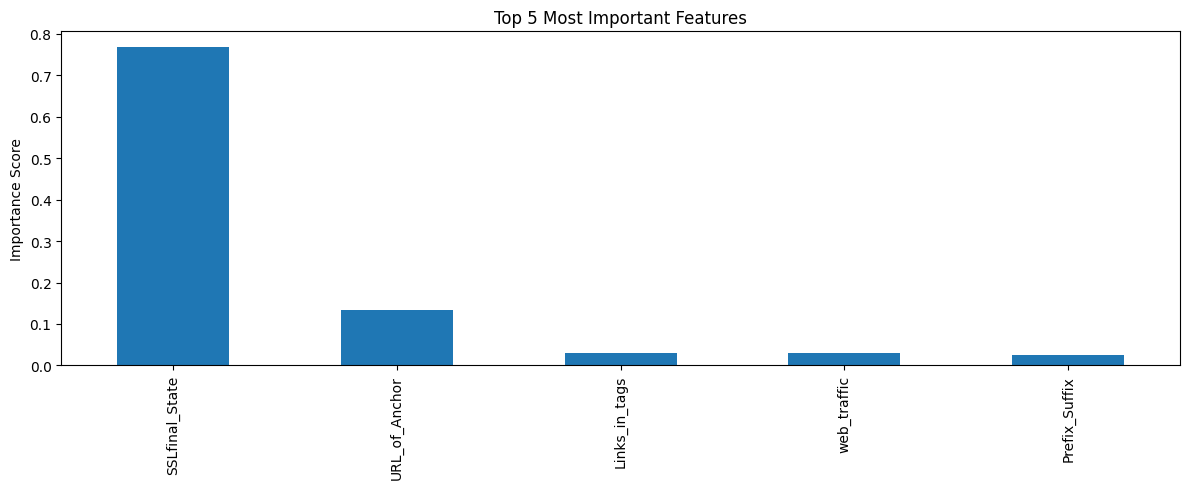

In [11]:
#feature importance
dt_model = results["Decision Tree"]["model"]
feature_names = df.drop('Result', axis=1).columns

importances = pd.Series(dt_model.feature_importances_, index=feature_names)
importances.sort_values(ascending=False).head(5).plot(kind='bar', figsize=(12,5))
plt.title("Top 5 Most Important Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

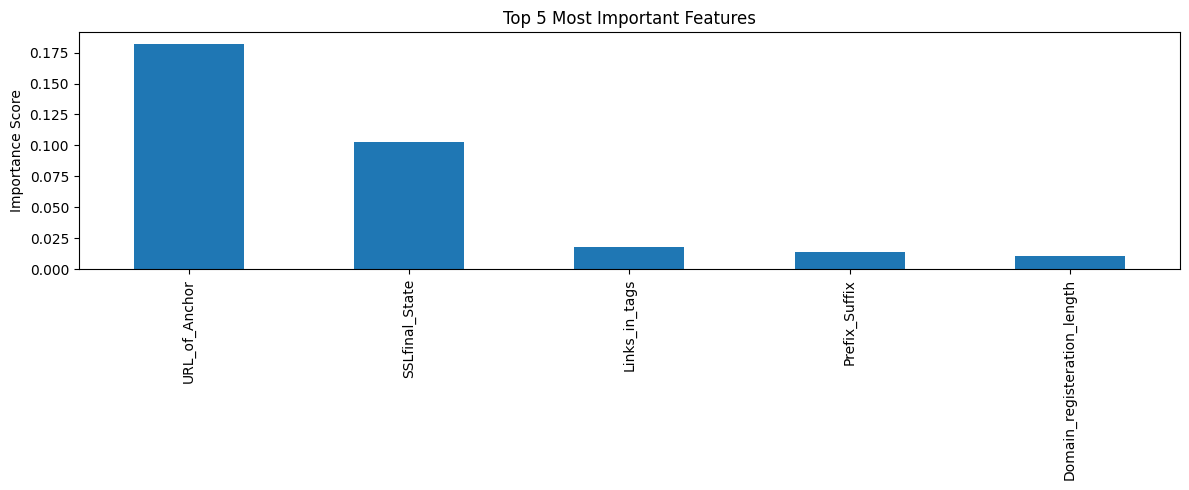

In [12]:
#permutation importance
dt_model = results["Decision Tree"]["model"]
feature_names = df.drop('Result', axis=1).columns

result = permutation_importance(dt_model, X_test, y_test, n_repeats=10, random_state=67)
importances = pd.Series(result.importances_mean, index=feature_names)

importances.sort_values(ascending=False).head(5).plot(kind='bar', figsize=(12,5))
plt.title("Top 5 Most Important Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [13]:
best_model = results["MLP"]["model"]
joblib.dump(best_model, 'phishing_classifier.pkl')
joblib.dump(scaler, 'scaler.pkl')
print ("Model Saved")

Model Saved


In [ ]:
def extract_features(url):
    """
    Extract features from a raw URL string
    Make sure each feature matches the UCI database format
    -1 = phishing indicator
    0 = Suspect
    1 = Clean/Non-Phishing Indicator
    """
    features = {}
    try:
        parsed = urllib.parse.urlparse(url)
        domain = parsed.netloc
        path = parsed.path
    except:
        return None
     
    ip_pattern = re.compile(r'\d+\.\d+\.\d+\.\d+')
    features['having_IP_Address'] = -1 if ip_pattern.search(url) else 1

    url_len = len(url)
    if (url_len < 54):
        features['URL_Length'] = 1
    elif (url_len <=75):
        features['URL_Length'] = 0
    else:
        features['URL_Length'] = -1

    shorteners = r'bit\.ly|goo\.gl|tinyurl|ow\.ly|t\.co|is\.gd'
    features['Shortining_Service'] = -1 if re.search(shorteners, url) else 1

    features['having_At_Symbol'] = -1 if '@' in url else 1

    last_double_slash = url.rfind('//')
    features['double_slash_redirecting'] = -1 if last_double_slash > 7 else 1

    features['Prefix_Suffix'] = -1 if '-' in domain else 1

    dot_count = domain.count('.')
    if dot_count == 1:
        features['having_Sub_Domain'] = 1
    elif dot_count == 2:
        features['having_Sub_Domain'] = 0
    else:
        features['having_Sub_Domain'] = -1

    features['HTTPS_token'] = -1 if 'https' in domain.lower() else 1

    return features

In [14]:
model = joblib.load('phishing_classifier.pkl')
scaler = joblib.load('scaler.pkl')

def predict_url_features(feature_values):
    features_scaled = scaler.transform([feature_values])
    prediction = model.predict(features_scaled)[0]
    return "Phishing URL" if prediction == -1 else "Good URL"
sample = X_test[0]
print (predict_url_features(sample))

Good URL


C:\Users\bshka\downloads\Cyber-Projects\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
#while(True):
    #url = input("Input a URL to check: ")
    #features = extract_features(url)
    #prediction = model.predict([listfeatures.values())])
    #print("Phishing Detected" if prediction[0]=1 else "Safe")